<!-- NINO26-CABECALHO v1 -->
# 4C — Sinal pixel-a-pixel, por região IBGE e por bioma

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `4C`  ·  **Hipótese:** HIP1

## Descritivo (por que este notebook existe)
Distribui o sinal Pacífico->chuva por pixel, região e bioma, por fase do ciclo — o coração espacial da teleconexão e o que sustenta ou refuta a hipótese NEB seco/Sul úmido.

## Pergunta
Onde, quando e com que sinal (seco/úmido) e em que lag o Pacífico altera a chuva do Brasil, por pixel/região/bioma?

## Desafio (hipótese a testar)
O alvo precisa manter os pixels CHIRPS nativos, semanas completas e escalas robustas; a significância exige N_eff, FDR e teste de campo por família.

## Metodologia (com referências)
Pacífico(t-lag)->CHIRPS(t) nos pixels originais, condicionado à fase em t-lag, para 31 variáveis e EN/LN x 4 fases; N_eff, BH-FDR e significância de campo, com região/bioma apenas como agregações reversíveis (Grimm & Tedeschi, 2009; Bretherton et al., 1999; Benjamini & Hochberg, 1995; Funk et al., 2015).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_4C01_lags_regiao_bioma_el_nino", fase=4, bloco="C",
                 titulo=..., descricao=..., hipotese="HIP1",
                 notebook="notebooks/fase4/4C_sinal_pixel_lags.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase4/<codigo>.png + numeric-tables/fase4/<codigo>/
```

| Código | Figura (`figures/fase4/<código>.png`) | Numeric-table (`numeric-tables/fase4/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_4C01_lags_regiao_bioma_el_nino` | `Fig_4C01_lags_regiao_bioma_el_nino.png` | `Fig_4C01_lags_regiao_bioma_el_nino/` | lags por região/bioma (El Niño) |
| `Fig_4C02_lags_regiao_bioma_la_nina` | `Fig_4C02_lags_regiao_bioma_la_nina.png` | `Fig_4C02_lags_regiao_bioma_la_nina/` | lags por região/bioma (La Niña) |
| `Fig_4C03_mapa_pixel_el_nino_pico` | `Fig_4C03_mapa_pixel_el_nino_pico.png` | `Fig_4C03_mapa_pixel_el_nino_pico/` | mapa nativo FDR no pico de El Niño |
| `Fig_4C04_mapa_pixel_la_nina_pico` | `Fig_4C04_mapa_pixel_la_nina_pico.png` | `Fig_4C04_mapa_pixel_la_nina_pico/` | mapa nativo FDR no pico de La Niña |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
for candidate in (ROOT, ROOT/'src'):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))
from scripts.notebook_run_viewer import audit_phase4_outputs, load_phase4_table

STATS = ROOT/'data/processed/parquet/statistics'
ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip() or None
if ENSO_TYPE not in {None, 'el_nino', 'la_nina'}:
    raise ValueError(f'NINO26_ENSO_TYPE invÃ¡lido: {ENSO_TYPE!r}')
SCOPE_SUFFIX = f'_{ENSO_TYPE}' if ENSO_TYPE else ''
FIGS = ROOT/'data/processed/figures/fase4'/(ENSO_TYPE or '')
ATLAS = ROOT/f'data/processed/zarr/statistics/phase4C_native_pixel_lags{SCOPE_SUFFIX}.zarr'
PREDICTOR_TREATMENT = STATS/f'phase4C_native_predictor_treatment{SCOPE_SUFFIX}.csv'
FIELD_SIGNIFICANCE = STATS/f'phase4C_native_field_significance{SCOPE_SUFFIX}.csv'
BEST_LAG_KEY = STATS/f'phase4C_native_best_lag_pixel_key{SCOPE_SUFFIX}.csv'
F4C_OUTPUTS = [
    STATS/f'phase4C_native_lags_por_unidade{SCOPE_SUFFIX}.csv',
    STATS/f'phase4C_native_cobertura_unidades{SCOPE_SUFFIX}.parquet',
    PREDICTOR_TREATMENT,
    STATS/f'phase4C_native_best_lag_pixel{SCOPE_SUFFIX}.parquet',
    BEST_LAG_KEY,
    FIELD_SIGNIFICANCE,
    ATLAS,
]


In [2]:
# Viewer por padrão: o notebook nunca recalcula silenciosamente.
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    from scripts.run_fase4c_regional import main as run4c
    run_args = ['--field-permutations', '199', '--replace-existing']
    if ENSO_TYPE:
        run_args.extend(['--enso-type', ENSO_TYPE])
    run4c(run_args)
else:
    print('Modo viewer: validando numeric-tables F4C canônicas existentes.')


Modo viewer: validando numeric-tables F4C canônicas existentes.


## Auditoria, catálogo das 31 variáveis e gates numéricos


In [3]:
audit_4c, run_id_4c = audit_phase4_outputs(
    F4C_OUTPUTS, canonical_f4c=True, expected_stage='F4C', expected_enso_type=ENSO_TYPE
)
display(audit_4c)
if run_id_4c is None:
    print('F4C canônica ausente ou inválida; nenhuma conclusão é exibida.')
else:
    print({'analysis_run_id': run_id_4c, 'artifacts_validated': len(F4C_OUTPUTS)})
    predictors = load_phase4_table(PREDICTOR_TREATMENT)
    print({'predictor_count': predictors['variavel'].nunique(),
           'selection_contract': sorted(predictors['selection_contract'].astype(str).unique())})
    display(predictors)
    field = load_phase4_table(FIELD_SIGNIFICANCE)
    display(field)
    key = load_phase4_table(BEST_LAG_KEY)
    display(key.head(40))


,artifact,run_id,stage,selection_contract,valid,problems
0,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
1,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
2,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
3,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
4,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
5,C:\DEV\NINO26\data\processed\parquet\statistic...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,
6,C:\DEV\NINO26\data\processed\zarr\statistics\p...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,F4C,canonical_all_31_physical_variables,True,


{'analysis_run_id': 'F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc67_845974', 'artifacts_validated': 7}
{'predictor_count': 31, 'selection_contract': ['canonical_all_31_physical_variables']}


,variavel,tratamento_sazonal_predictor,climatologia_inicio,climatologia_fim,n_harmonicos,n_semanas_ajuste,selection_contract,grid_hash_sha256,analysis_run_id,parent_f3_run_id,...,target_build_id,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,lag_analysis_module_sha256,predictor_count,predictor_catalog_sha256
0,nino34_ssta,previamente_anomalia,1991-01-01,2020-12-31,0,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
1,d20_m,anomalia_harmonica_3,1991-01-01,2020-12-31,3,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
2,tilt_m,anomalia_harmonica_3,1991-01-01,2020-12-31,3,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
3,tilt_slope,anomalia_harmonica_3,1991-01-01,2020-12-31,3,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
4,ohc_0_100,anomalia_harmonica_3,1991-01-01,2020-12-31,3,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
5,ohc_0_300,anomalia_harmonica_3,1991-01-01,2020-12-31,3,1565,canonical_all_31_physical_variables,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,F4C_20260713T180931Z_4422ba2d_5142b6cf_4f9efc6...,20260713T152012Z_4f9efc67,...,F4TARGET_20260713T153619Z_5142b6cfd8,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb39

,lag_sem,point_alpha,fracao_campo_ponto_significativo,fracao_nula_media,fracao_nula_p95,p_field_por_lag,p_field_max_lag,n_permutacoes_campo,field_significant_confirmatory_max_lag,metodo_field,...,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,lag_analysis_module_sha256,selection_contract,predictor_count,predictor_catalog_sha256
0,0,0.05,0.0,0.122613,0.4,1.000,1.000,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
1,2,0.05,0.6,0.112563,0.4,0.025,0.510,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
2,4,0.05,0.6,0.130653,0.4,0.035,0.510,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
3,6,0.05,0.4,0.122613,0.4,0.140,0.955,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
4,8,0.05,0.4,0.130653,0.4,0.155,0.955,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,70,0.05,0.0,0.075377,0.4,1.000,1.000,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
316,72,0.05,0.0,0.065327,0.4,1.000,1.000,199,False,whole-field circular temporal shift; affected-...,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c

,pixel_id,grid_row,grid_column,lat,lon,grid_hash,native_pixel,interpolated,brazil_fraction,brazil_center,...,target_block_signature_sha256,target_contract_version,ibge_regions_bundle_sha256,ibge_biomes_bundle_sha256,ibge_geometry_bundle_sha256,f4c_runner_sha256,lag_analysis_module_sha256,selection_contract,predictor_count,predictor_catalog_sha256
0,774,4,86,-33.875,-53.375,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.000094,False,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
1,945,5,85,-33.625,-53.625,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.082686,False,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
2,946,5,86,-33.625,-53.375,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.842753,True,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
3,947,5,87,-33.625,-53.125,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.264802,False,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
4,1117,6,85,-33.375,-53.625,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.052383,False,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
5,1118,6,86,-33.375,-53.375,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,1.000000,True,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
6,1119,6,87,-33.375,-53.125,4422ba2d57f6d8665401ae2d437c12e18b07fc9dbc76c6...,True,False,0.985903,True,...,5142b6cfd834114addde6fa4f221be34e8f1a5cebdb993...,chirps-native-weekly-v4,22ee33c1321d68e2eba7bf34d440447f602cb399c1dbca...,5d222839f7c7eb7ed049274f6369392c4e9d6e320194aa...,fd46adcc9420cafbea9c9fb85b0246f78964c36e2b7c7c...,826c5a4f4637daa9384d9e16a9943b8ba108842968c02c...,a09c98f45bddc1a59fcb6892b1f1e724522492a4380ec6...,canonical_all_31_physical_variables,31,3832345fbb7b5df3ba434fbe106449dd8bd4315d4d73f3...
7,1120,6,88

## Figuras derivadas das numeric-tables validadas


Fig_4C01_lags_regiao_bioma_el_nino.png


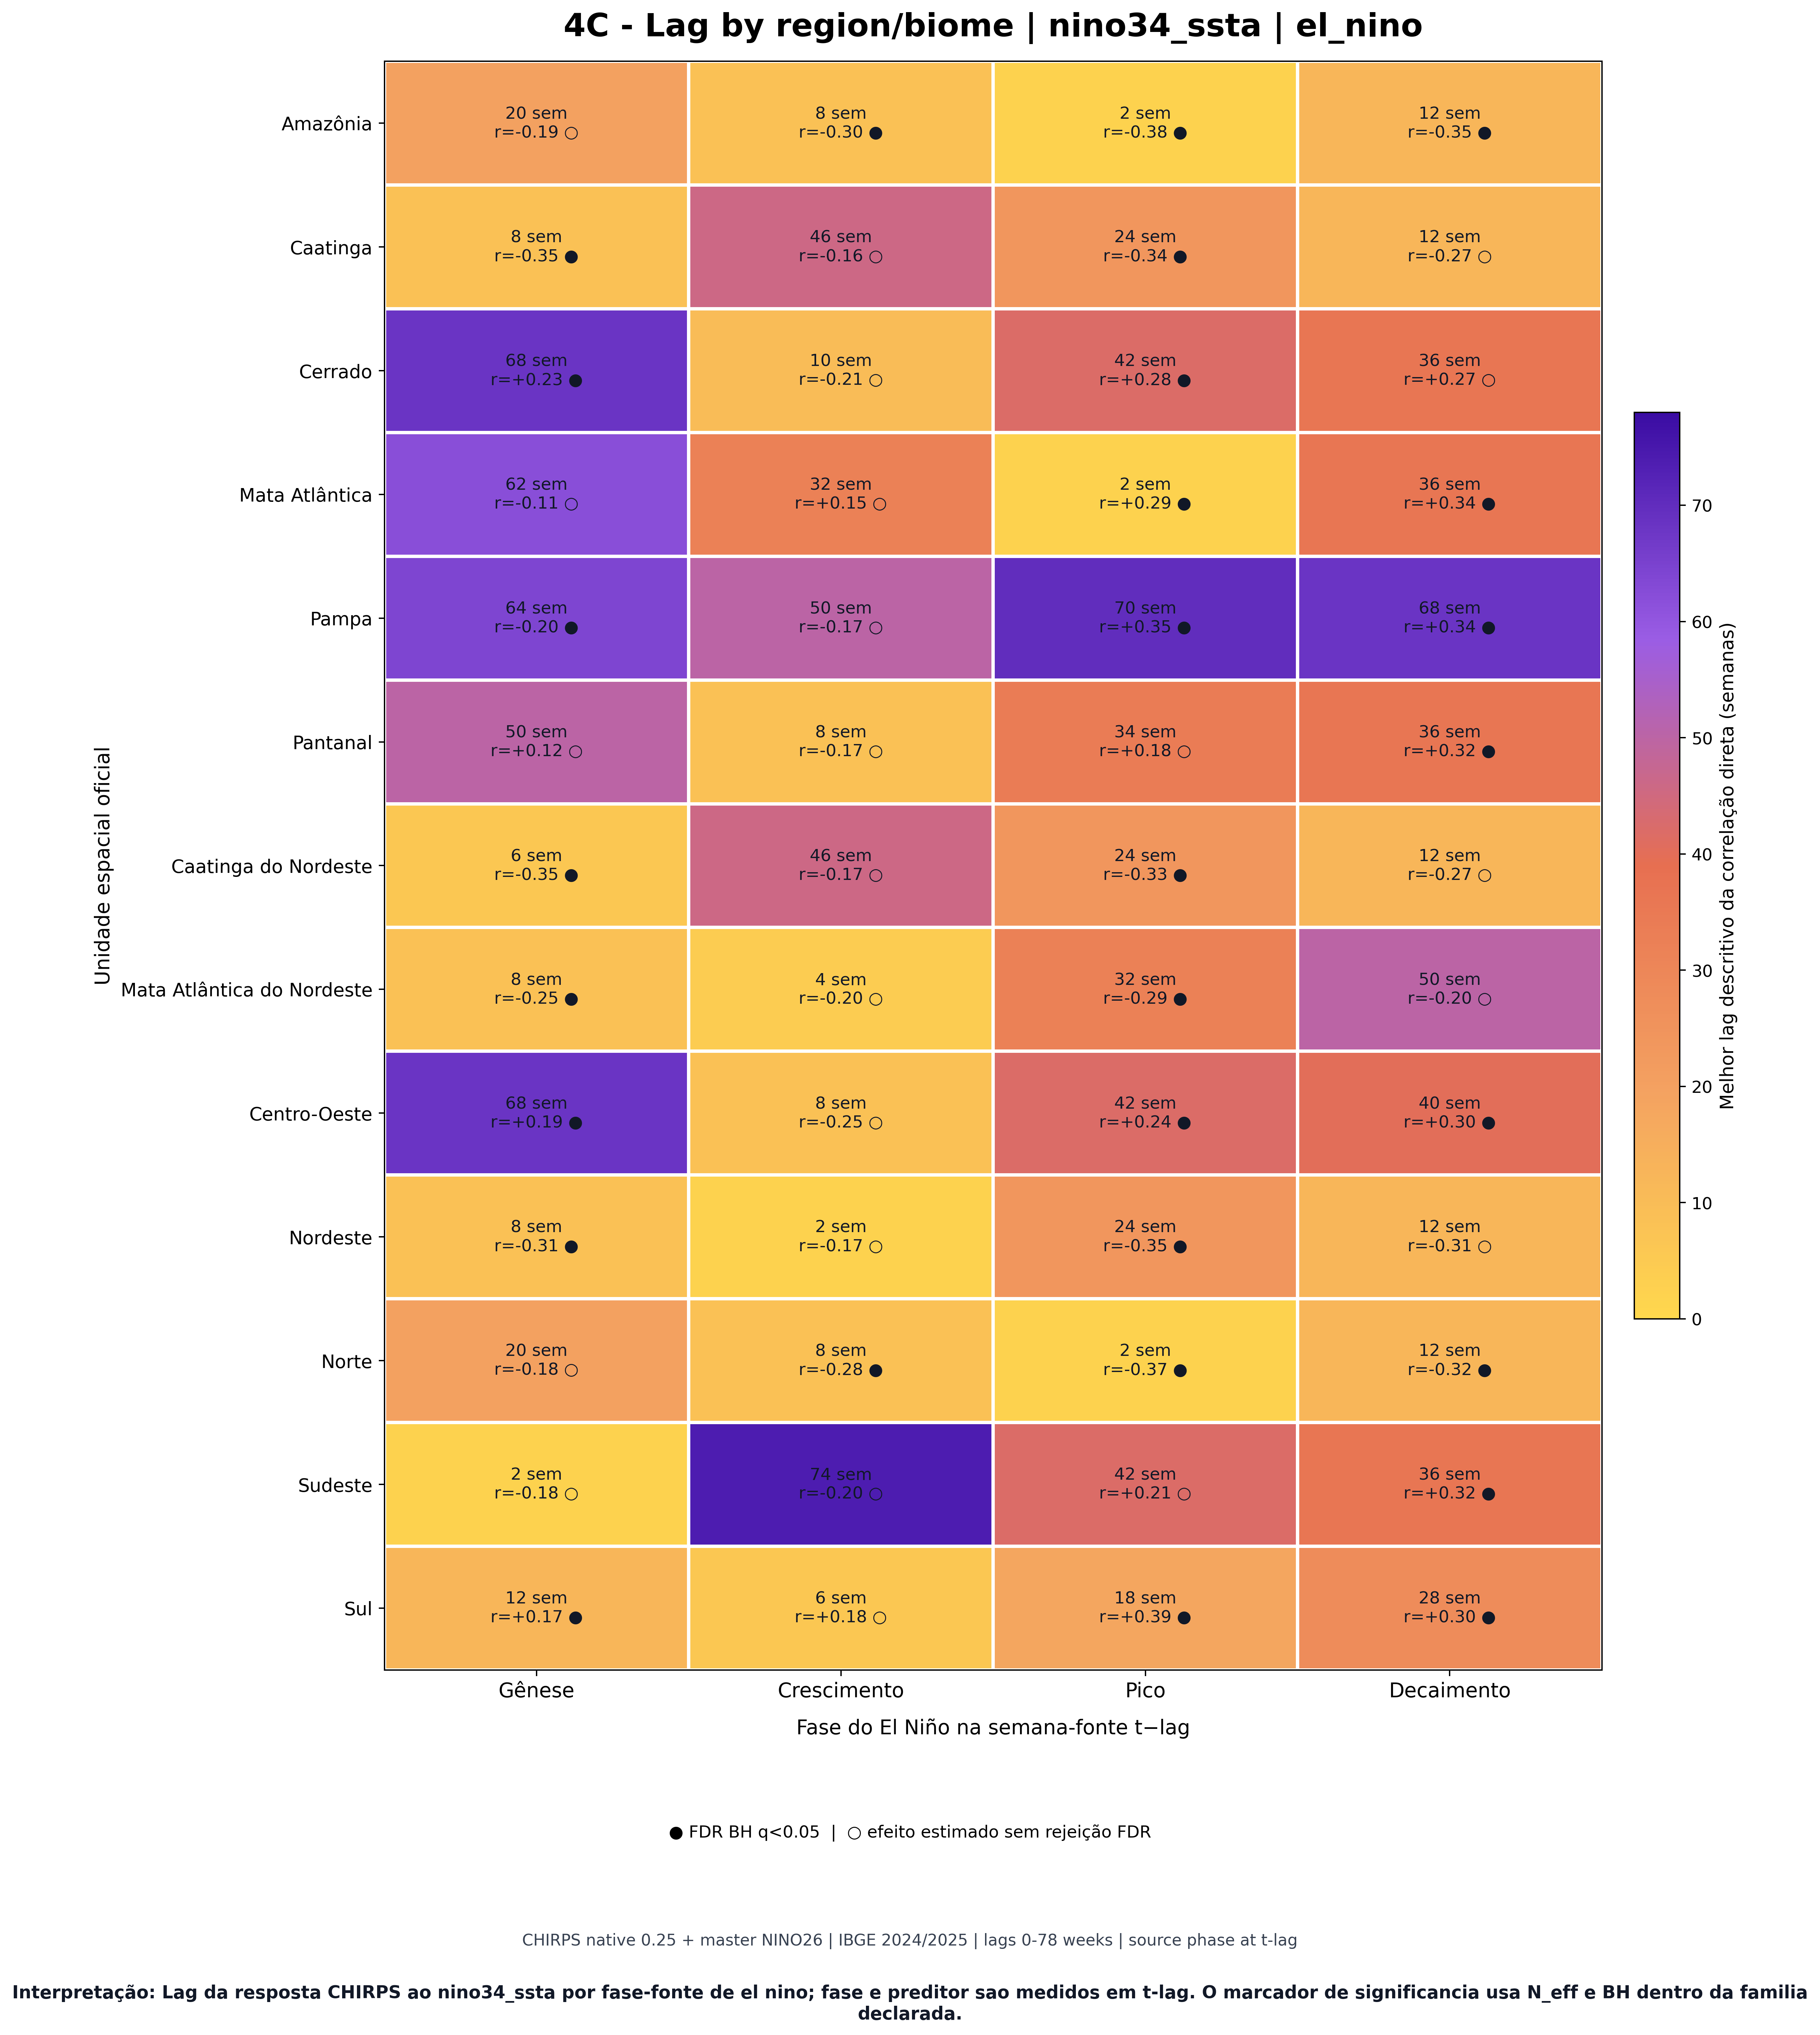

Fig_4C02_lags_regiao_bioma_la_nina.png


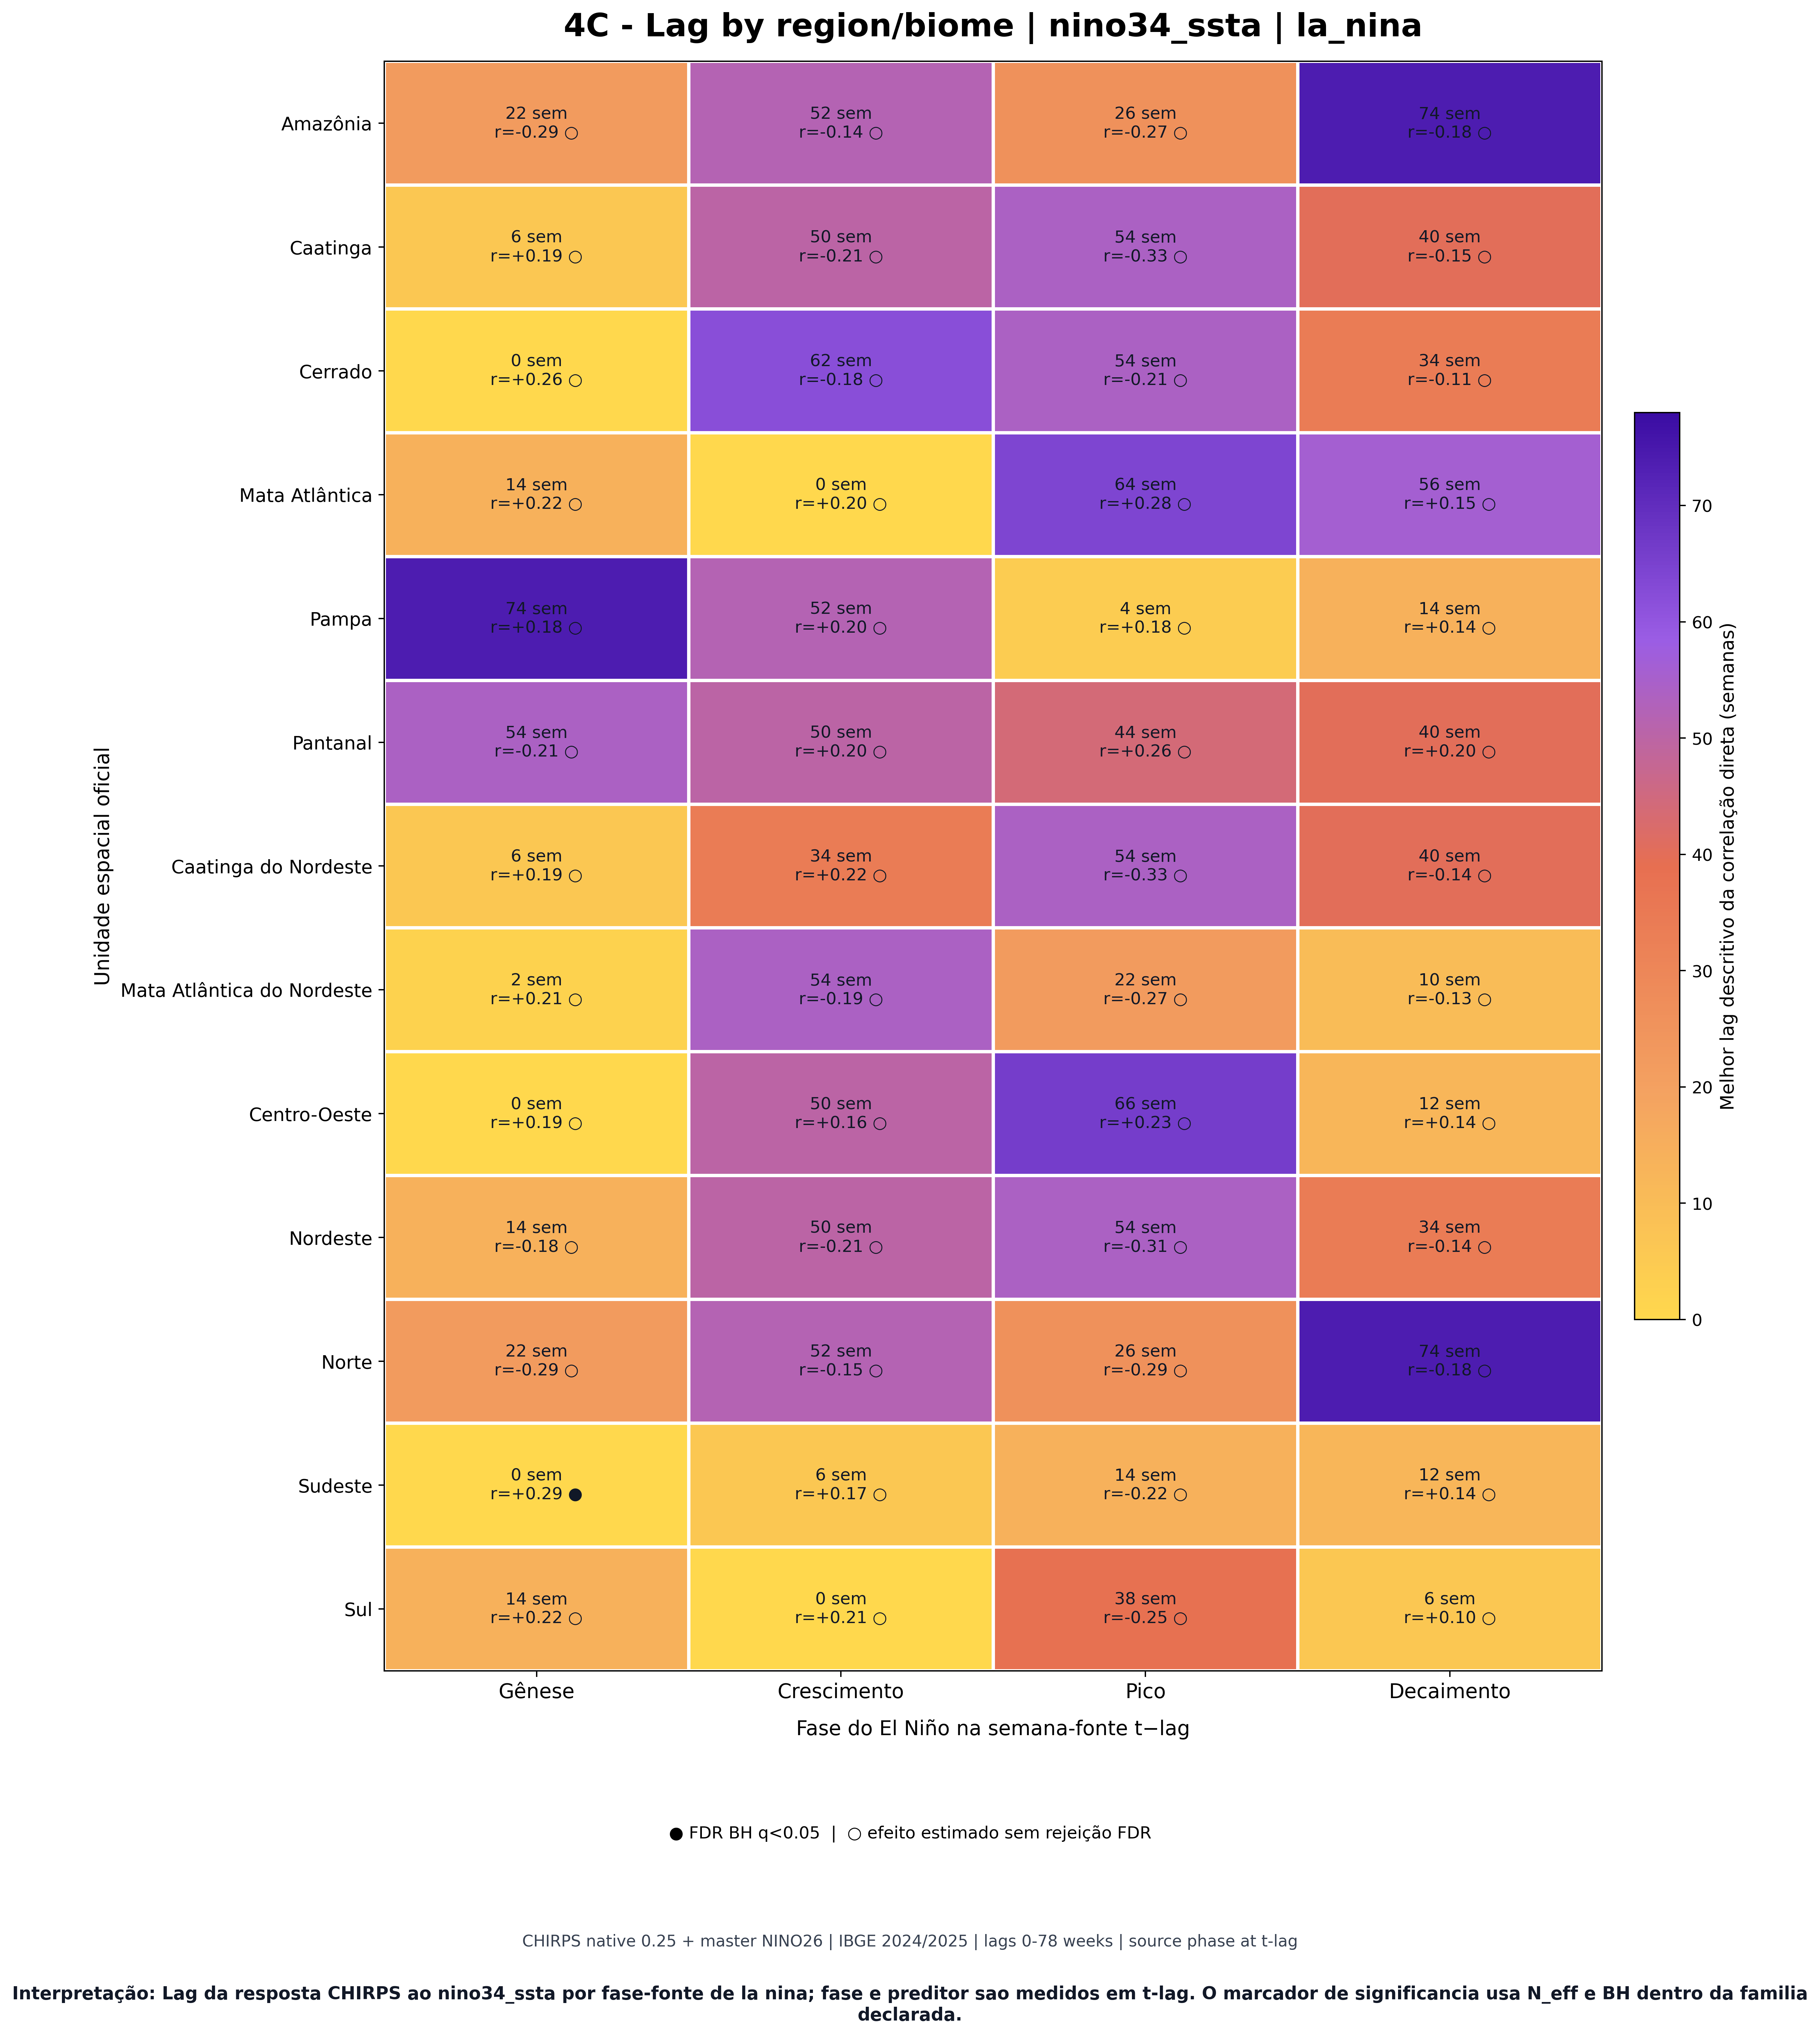

Fig_4C03_mapa_pixel_el_nino_pico.png


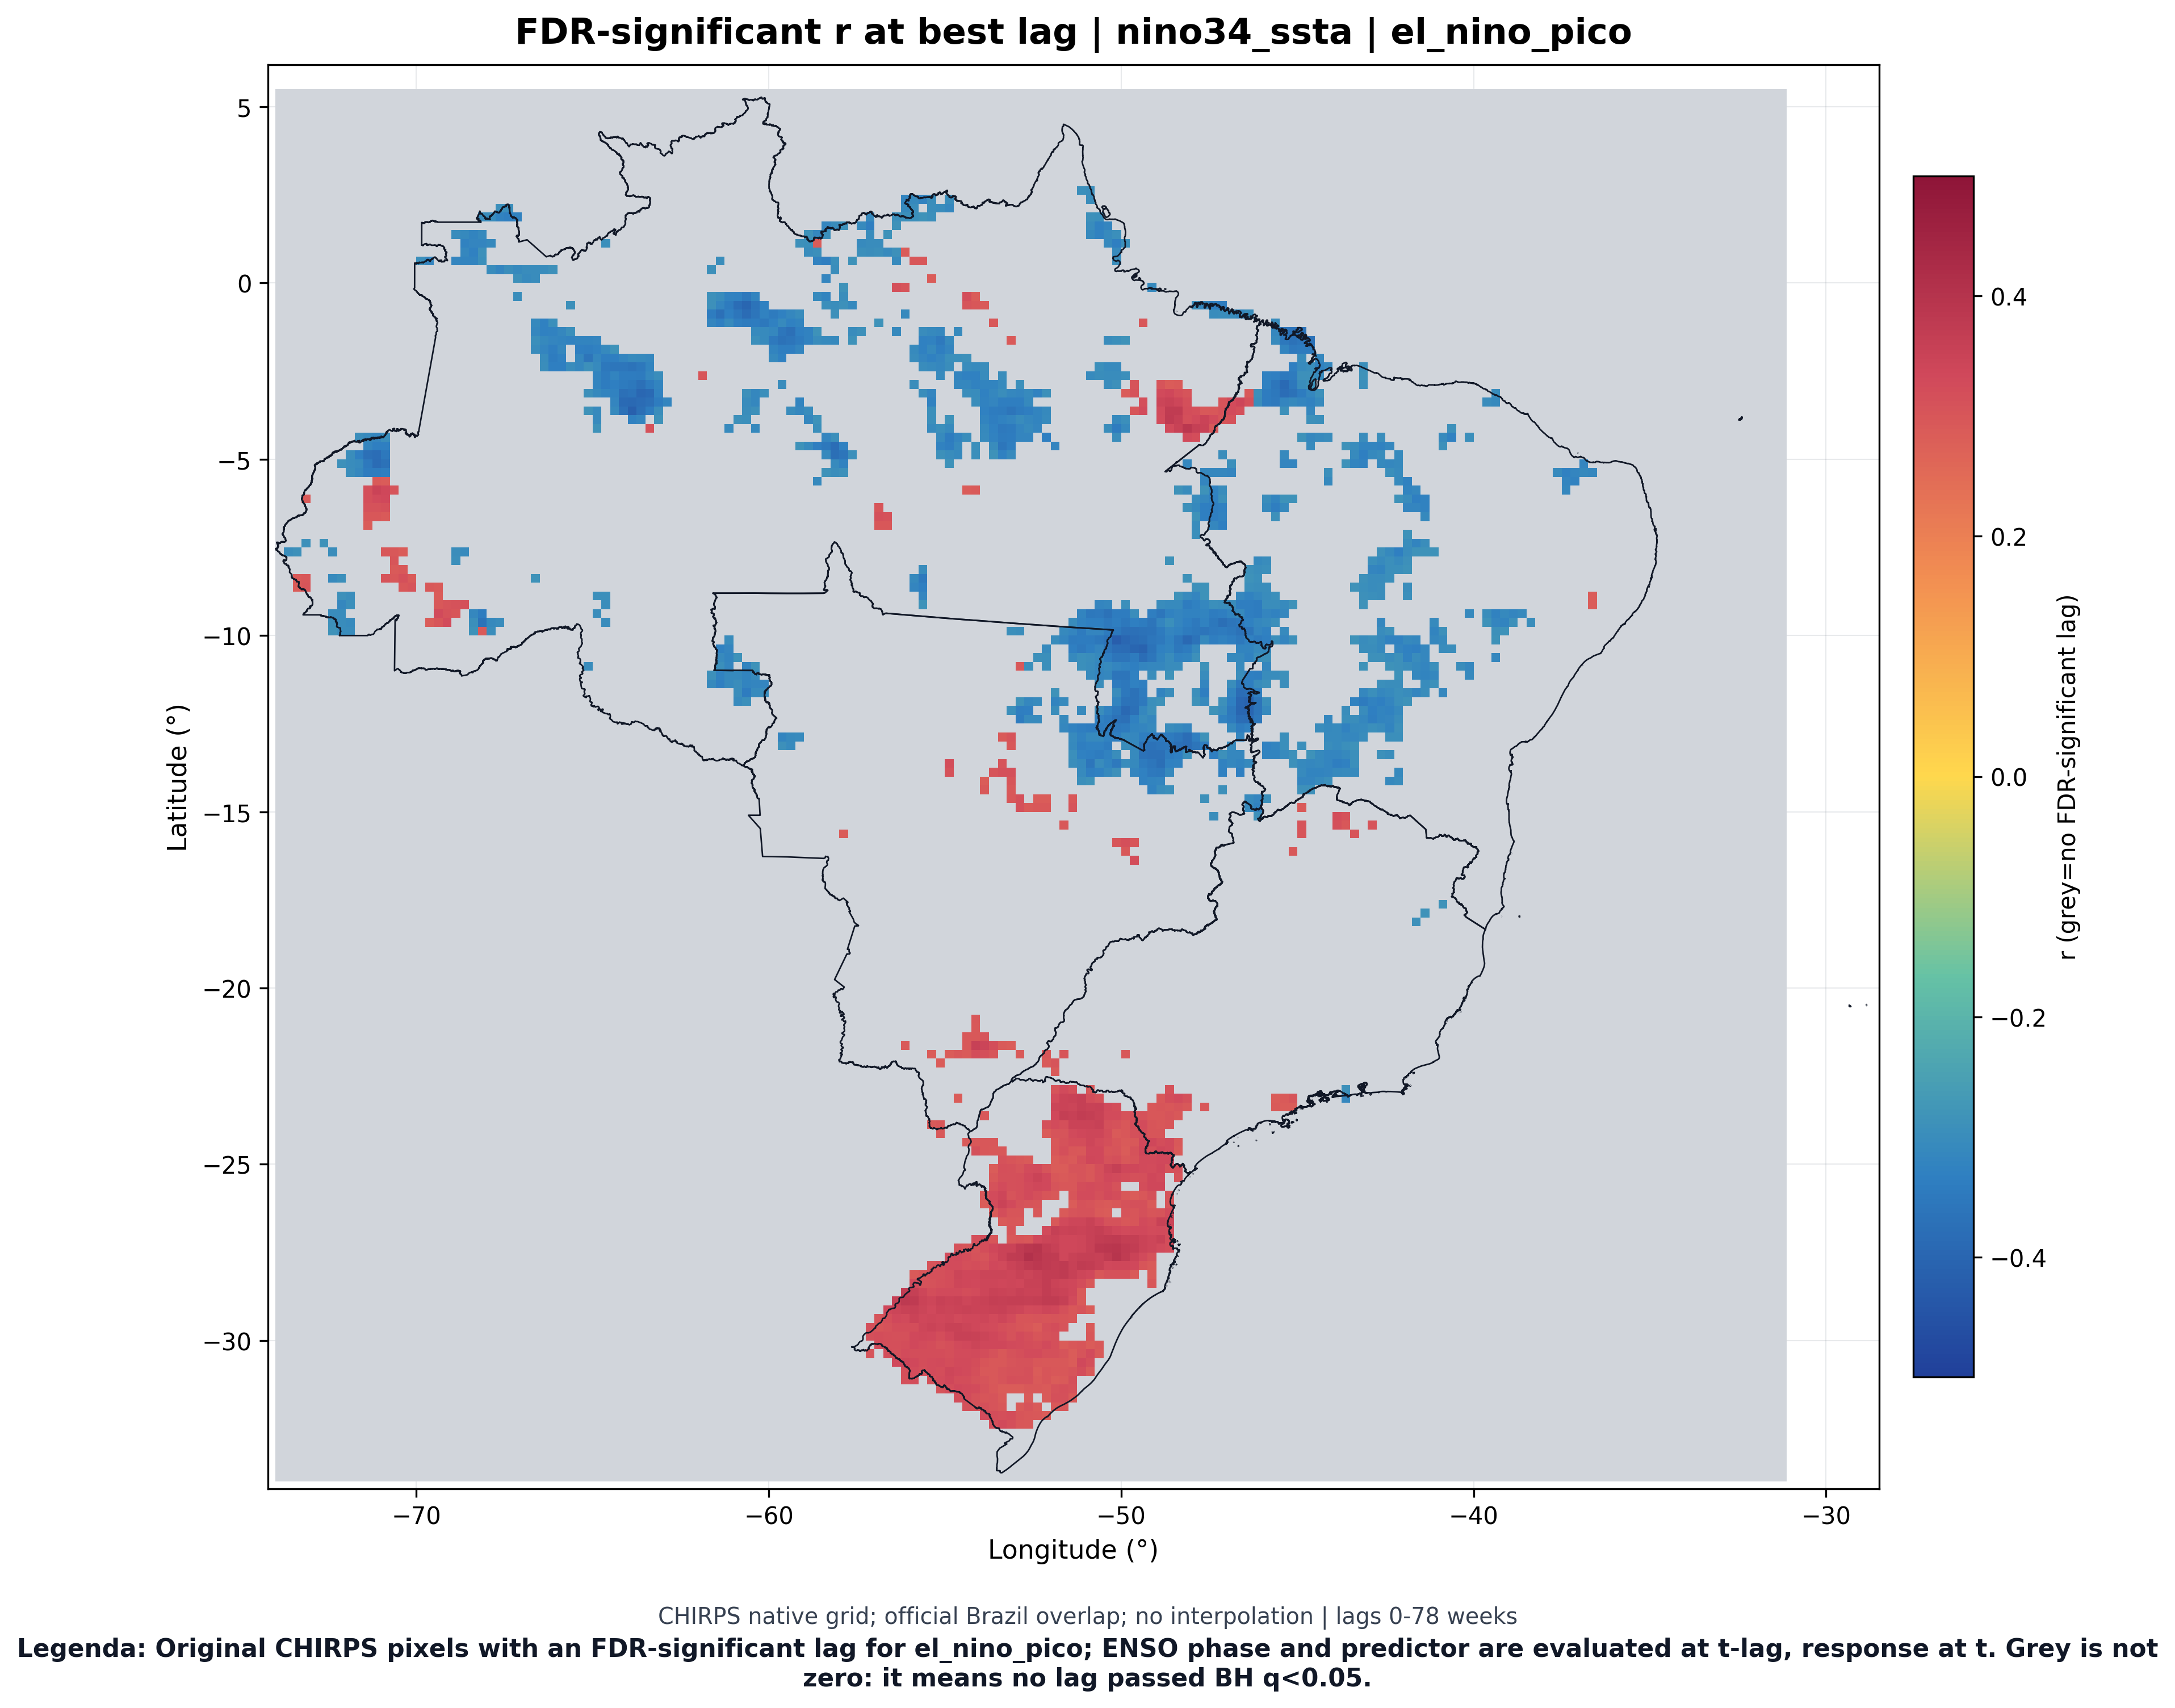

Fig_4C04_mapa_pixel_la_nina_pico.png


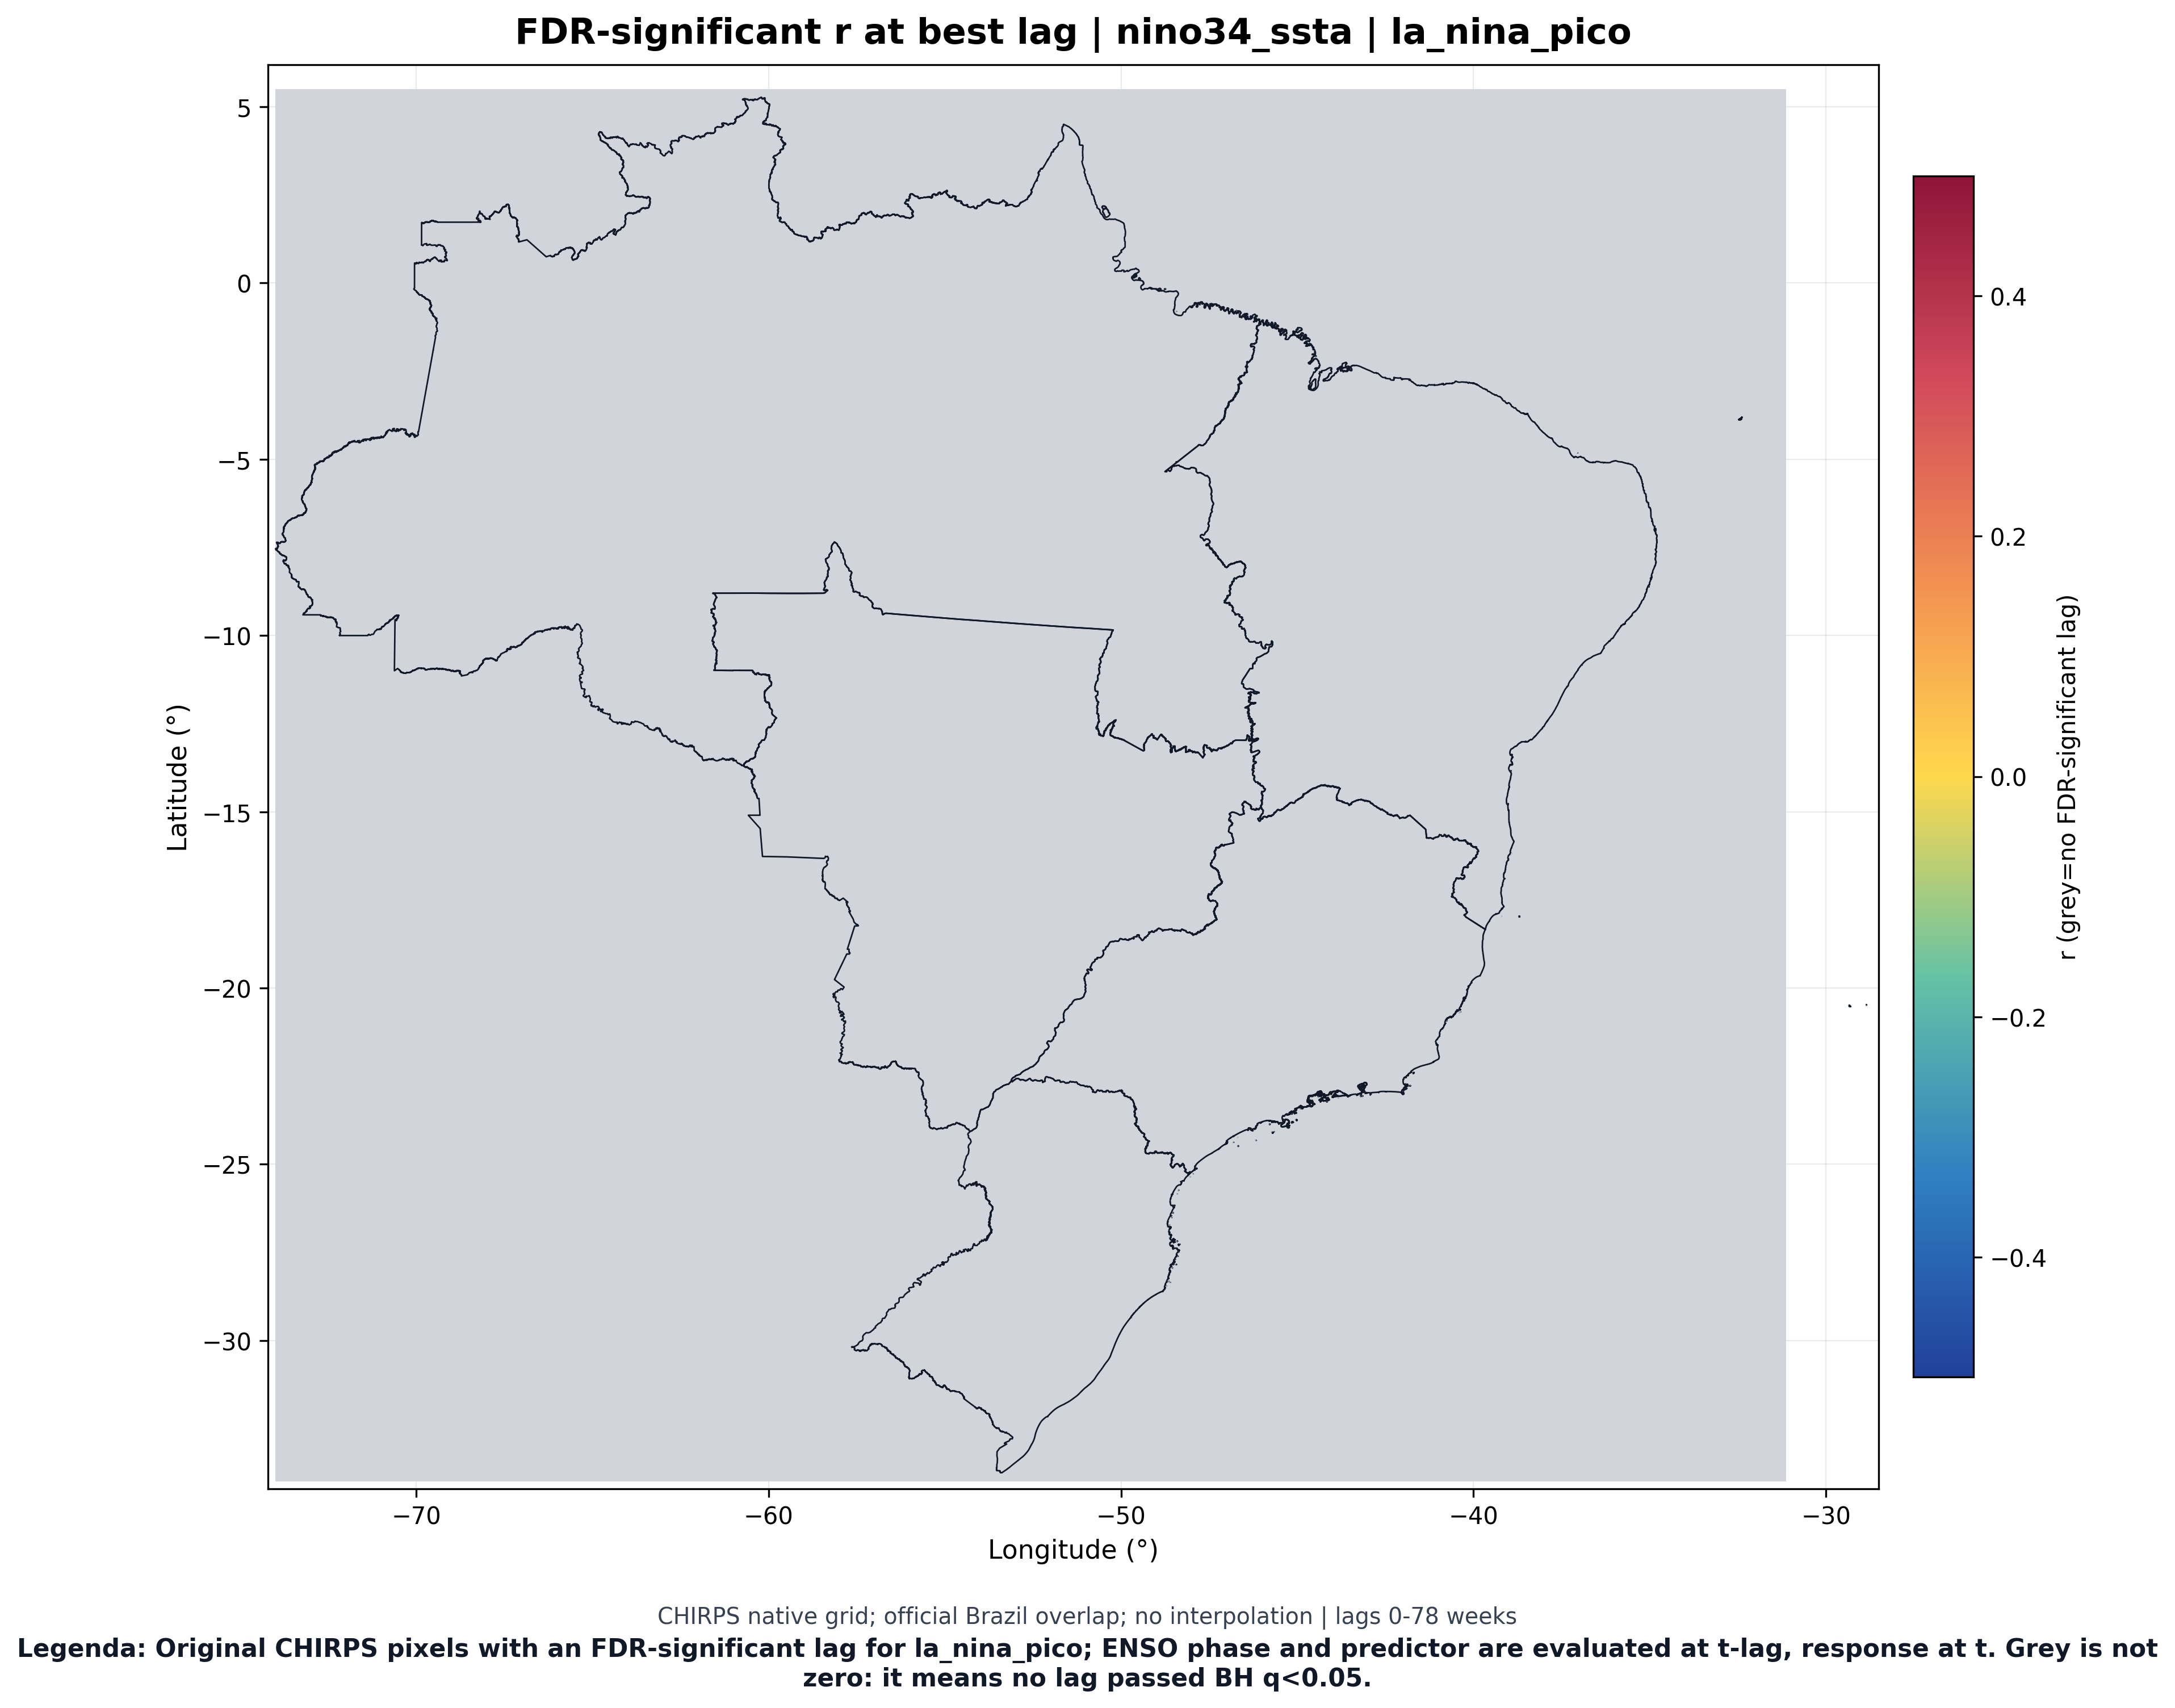

In [4]:
if run_id_4c is not None:
    figures = sorted(FIGS.glob('Fig_4C*.png'))
    if not figures:
        print('Nenhuma figura F4C canônica registrada para o run validado.')
    for figure in figures:
        print(figure.name)
        display(Image(filename=str(figure)))


**Leitura do 4C.** Interprete separadamente El Nino/La Nina e as quatro fases-fonte.
Cinza nao e efeito zero: significa que nenhum lag passou a familia FDR declarada.
Uma conclusao espacial exige tambem a tabela de significancia de campo; o sentido
Nordeste seco/Sul umido e hipotese a testar, nao premissa do grafico.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Grimm, A. M., & Tedeschi, R. G. (2009). ENSO and Extreme Rainfall Events in South America. *J. Climate*, 22, 1589-1609. https://doi.org/10.1175/2008JCLI2429.1
2. Bretherton, C. S., et al. (1999). The Effective Number of Spatial Degrees of Freedom. *J. Climate*, 12, 1990-2009. https://doi.org/10.1175/1520-0442(1999)012<1990:TENOSD>2.0.CO;2
3. Benjamini, Y., & Hochberg, Y. (1995). Controlling the False Discovery Rate. *JRSS-B*, 57, 289-300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
4. Funk, C., et al. (2015). CHIRPS. *Scientific Data*, 2, 150066. https://doi.org/10.1038/sdata.2015.66
5. Cai, W., et al. (2020). Climate impacts of ENSO on South America. *Nat. Rev. Earth Environ.*, 1, 215-231. https://doi.org/10.1038/s43017-020-0040-3

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.